# **Exploring Intra-tumor Heterogeneity in Cancer: A Comparative Evaluation of Clustering Methods**

* Intra-tumor heterogeneity (ITH) refers to the genetic diversity in the population of cancer cells within a single tumor. This diversity originates from the accumulation of mutations over time, driven by clonal evolution, and can directly impact tumor growth, response to treatment, and the emergence of therapeutic resistance.

* Identification of subclones through mutational profiles enables a better understanding of cancer clonal evolution, which is a key step toward the development of personalized and more effective treatment strategies.

* In this notebook, we implement a systematic analysis of clustering methods to group mutations extracted from individual tumor samples based on MAF (Mutation Annotation Format) files.

* The main objective is to assess whether specific clustering algorithms perform better in identifying mutational patterns associated with different cancer types.


<br><br><br>

---


# **1) Input**

- The input for the method must be a MAF (Mutation Annotation Format) file, a tab-delimited file containing mutations found in tumor samples.

- The MAF columns utilized in this analysis are listed in the "maf_columns" object within the "Reading the MAF file" section.


<br>

<h3> <strong> Uploading the input MAF file </strong> </h3>

* Run the cell below and upload the MAF file using the button shown in the cell output.

* After uploading the input datasets, run the next cells.



In [ ]:
from google.colab import files
uploaded_file = files.upload()
maf_file_name = list(uploaded_file.keys())[0]


Saving lymphoma_mbn_msk_2024.txt to lymphoma_mbn_msk_2024.txt


<br><br><br>

---


# **2) Initial configuration**

* In this section, the required libraries are imported, and the variables used throughout the notebook are initialized.

In [ ]:
# Import libraries
import os
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Ignore all warnings
warnings.filterwarnings("ignore")

# Create the output folders
graphs_output_dir = "Output/Graphs"
tables_output_dir = "Output/Tables"
os.makedirs(graphs_output_dir, exist_ok=True)
os.makedirs(tables_output_dir, exist_ok=True)


<br>

### **Print MAF information**


In [ ]:
def print_title(title): print("\n", title, "\n", "="*len(title), sep="")

def print_inf_maf_data(maf_df):
    # Obtaining all unique tumor samples from MAF
    num_unique_samples = maf_df["Tumor_Sample_Barcode"].unique()

    # Obtaining all unique mutations from MAF
    num_unique_genes = maf_df["Hugo_Symbol"].unique()

    # Create the DataFrame with the number of mutations in each tumor sample
    number_mutations_df = maf_df.groupby("Tumor_Sample_Barcode").size().reset_index(name="Number of mutations")
    number_mutations_df = number_mutations_df.rename(columns={"Tumor_Sample_Barcode": "Sample"})

    # Calculate the mean and median of the number of mutations per sample
    mean_mutations = number_mutations_df["Number of mutations"].mean()
    median_mutations = number_mutations_df["Number of mutations"].median()

    # Print the results
    print_title("Information from the MAF data:")
    print(f"   Total mutations: {len(maf_df)}")
    print(f"   Number of unique tumor samples: {len(num_unique_samples)}")
    print(f"   Number of unique genes: {len(num_unique_genes)}")
    print(f"   Mean number of mutations per sample: {mean_mutations:.0f}")
    print(f"   Median number of mutations per sample: {median_mutations:.0f}")


<br><br><br>

---


# **3) Reading the MAF file**

- In this section, we read the MAF file and create a DataFrame containing only the columns used in this analysis.

- We also calculate the Variant Allele Frequency (VAF) of each mutation from the MAF and insert it into the DataFrame.

- Note: The VAF indicates the proportion of a variant allele in a gene in the cells of a sample.

In [ ]:
# MAF columns that will be in the dataframe
maf_columns = ["Hugo_Symbol", "Variant_Classification", "Variant_Type", "Tumor_Sample_Barcode",
               "t_ref_count", "t_alt_count", "n_ref_count", "n_alt_count"]
               # "t_ref_count", "t_alt_count", "n_ref_count", "n_alt_count", "n_depth", "t_depth"]

# Create the dataframe ignoring comment lines
maf_df = pd.read_csv(maf_file_name, sep="\t", usecols=maf_columns, comment="#")

maf_df["n_depth"] = maf_df["n_ref_count"] + maf_df["n_alt_count"]
maf_df["t_depth"] = maf_df["t_ref_count"] + maf_df["t_alt_count"]

# Calculate the VAF
maf_df["VAF"] = maf_df["t_alt_count"] / (maf_df["t_ref_count"] + maf_df["t_alt_count"])

print_inf_maf_data(maf_df)



Information from the MAF data:
   Total mutations: 5711
   Number of unique tumor samples: 396
   Number of unique genes: 364
   Mean number of mutations per sample: 14
   Median number of mutations per sample: 11


<br><br><br>

---


# **4) Data preprocessing**

<br>

### **Filtering mutations**

  - Filtering MAF mutations according to the following criteria:

    - Removal of mutations with missing values in critical columns.

    - Selection of only single nucleotide variants (SNVs).

    - Filtering based on tumor and normal read depth and allele counts.

    - Selection of only non-silent mutations with potential functional impact.


In [ ]:
#  Remove rows with missing values in critical columns
critical_columns = ["Hugo_Symbol", "t_ref_count", "t_alt_count"]
maf_df.dropna(subset=critical_columns, inplace=True)

# Check if normal sample data is mostly missing
missing_normal_info = maf_df[["n_ref_count", "n_alt_count"]].isna().mean().mean() > 0.8

# Tumor sample: ≥8 total reads, ≥3 alt reads
tumor_filter = (maf_df["t_depth"] >= 8) & (maf_df["t_alt_count"] >= 3)

if missing_normal_info:
    # If normal sample data is missing, apply only the tumor sample filter
    print("Applying filter only to tumor samples (normal sample data missing)")
    maf_df = maf_df[tumor_filter]
else:
    print("Applying filter for normal and tumor samples")

    # Normal sample: ≥6 total reads, ≤1 alt read OR VAF < 1%
    normal_filter = ((maf_df["n_depth"] >= 6) & ((maf_df["n_alt_count"] <= 1) | (maf_df["n_alt_count"]/(maf_df["n_ref_count"] + maf_df["n_alt_count"]) < 0.01)))

    # Filter by number of reads and depth of normal and tumor samples
    maf_df = maf_df[tumor_filter & normal_filter]

# Filter for non-silent mutations
non_silent_mutations = [
    "Frame_Shift_Del", "Frame_Shift_Ins", "In_Frame_Del", "In_Frame_Ins",
    "Missense_Mutation", "Nonsense_Mutation", "Nonstop_Mutation",
    "Splice_Site", "Translation_Start_Site"
]
maf_df = maf_df[maf_df["Variant_Classification"].isin(non_silent_mutations)]

print_inf_maf_data(maf_df)


Applying filter for normal and tumor samples

Information from the MAF data:
   Total mutations: 5656
   Number of unique tumor samples: 395
   Number of unique genes: 361
   Mean number of mutations per sample: 14
   Median number of mutations per sample: 11


<br>

### **Filtering hypermutated samples**

  - Hypermutated samples should be excluded as they are often noisy outliers, which can distort analyses of clustering methods.


In [ ]:
# Count mutations per sample
mutations_per_sample = maf_df["Tumor_Sample_Barcode"].value_counts()

# Calculate Q1, Q3 and IQR
Q1 = mutations_per_sample.quantile(0.25)
Q3 = mutations_per_sample.quantile(0.75)
IQR = Q3 - Q1
threshold = min(Q3 + 4.5 * IQR, 600)

# Remove hypermutated samples from the dataframe
hypermutated_samples = mutations_per_sample[mutations_per_sample > threshold].index.tolist()
maf_df = maf_df[~maf_df["Tumor_Sample_Barcode"].isin(hypermutated_samples)]

print_inf_maf_data(maf_df)



Information from the MAF data:
   Total mutations: 5051
   Number of unique tumor samples: 388
   Number of unique genes: 349
   Mean number of mutations per sample: 13
   Median number of mutations per sample: 11


<br>

### **Filtering samples with few mutations**

  - Removing tumor samples with an insufficient number of mutations to ensure that clustering methods have enough data to identify meaningful patterns.



In [ ]:
# Count mutations per sample
mutations_per_sample = maf_df["Tumor_Sample_Barcode"].value_counts()

# Set the minimum threshold of mutations per sample
min_mutations = 5

# Filter samples that have enough mutations
valid_samples = mutations_per_sample[mutations_per_sample >= min_mutations].index.tolist()
maf_df = maf_df[maf_df["Tumor_Sample_Barcode"].isin(valid_samples)]

print_inf_maf_data(maf_df)



Information from the MAF data:
   Total mutations: 4893
   Number of unique tumor samples: 327
   Number of unique genes: 347
   Mean number of mutations per sample: 15
   Median number of mutations per sample: 13


<br>

### **Summary statistics**

* Calculate and print information from the pre-processed MAF data:

  - The number of unique tumor samples

  - The mean and median number of mutations per tumor sample



In [ ]:
# Obtaining all unique tumor samples from MAF after data preprocessing
tumor_samples = maf_df["Tumor_Sample_Barcode"].unique()

# Create the DataFrame with the number of mutations in each tumor sample
number_mutations_df = maf_df.groupby("Tumor_Sample_Barcode").size().reset_index(name="Number of mutations")
number_mutations_df = number_mutations_df.rename(columns={"Tumor_Sample_Barcode": "Sample"})

# Calculate the mean and median of the number of mutations per sample
mean_mutations = number_mutations_df["Number of mutations"].mean()
median_mutations = number_mutations_df["Number of mutations"].median()

# Print the results
print(f"Number of unique tumor samples: {len(tumor_samples)}")
print(f"Mean number of mutations per sample: {mean_mutations:.0f}")
print(f"Median number of mutations per sample: {median_mutations:.0f}")


Number of unique tumor samples: 327
Mean number of mutations per sample: 15
Median number of mutations per sample: 13


In [ ]:
number_mutations_df

,Sample,Number of mutations
0,P-0004327-T03-IH3,11
1,P-0007306-T02-IH3,12
2,P-0011425-T02-IH3,28
3,P-0011498-T02-IH3,16
4,P-0012690-T02-IH3,23
...,...,...
322,P-0066110-T01-IH3,8
323,P-0066826-T01-IH3,10
324,P-0066826-T02-IH3,10
325,P-0067025-T01-IH3,38


<br><br><br>

---


# **5) Functions used in clustering**

  - In this section, different functions are implemented to be used in mutation clustering.

<br>

### **Clustering methods**

- In this subsection, clustering algorithms that do not require the number of clusters to be specified are implemented.

- Included methods:
  * Affinity Propagation (AP)
  * DBSCAN
  * HDBSCAN
  * Mean-Shift
  * OPTICS
  * Variational Bayesian Gaussian Mixture Model (VBGMM)

In [ ]:
# Affinity propagation (AP)
from sklearn.cluster import AffinityPropagation
def affinity_propagation_clustering(vaf_mutation_data, damping=0.7, max_iter=200, convergence_iter=100):
    af = AffinityPropagation(damping=damping, max_iter=max_iter,convergence_iter=convergence_iter, random_state=42)
    cluster_labels = af.fit_predict(vaf_mutation_data)
    return cluster_labels


# DBSCAN
from sklearn.cluster import DBSCAN
def dbscan_clustering(vaf_mutation_data, eps=0.1, min_samples=5):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    cluster_labels = dbscan.fit_predict(vaf_mutation_data)
    return cluster_labels


# HDBSCAN
import hdbscan
#def hdbscan_clustering(vaf_mutation_data, min_cluster_size=5, min_samples=None):
def hdbscan_clustering(vaf_mutation_data, min_cluster_size=3, min_samples=None):
    hdb = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
    cluster_labels = hdb.fit_predict(vaf_mutation_data)
    return cluster_labels


# Mean-Shift
from sklearn.cluster import MeanShift, estimate_bandwidth
def meanshift_clustering(vaf_mutation_data, quantile=0.2):
    # Estimate bandwidth based on the quantile
    bandwidth = estimate_bandwidth(vaf_mutation_data, quantile=quantile, random_state=42)

    if bandwidth is None or bandwidth <= 0:
        bandwidth = 0.1

    # Fit Mean-Shift model
    meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    cluster_labels = meanshift.fit_predict(vaf_mutation_data)
    return cluster_labels


# OPTICS
from sklearn.cluster import OPTICS
def optics_clustering(vaf_mutation_data, min_samples=5, max_eps=np.inf):
    optics_model = OPTICS(min_samples=min_samples, max_eps=max_eps)
    cluster_labels = optics_model.fit_predict(vaf_mutation_data)
    return cluster_labels


# Variational Bayesian Gaussian Mixture (VBGMM)
from sklearn.mixture import BayesianGaussianMixture
def vbgmm_clustering(vaf_mutation_data, n_components=2):
    # Creates and adjusts the VBGMM model
    vbgmm = BayesianGaussianMixture(n_components=n_components, covariance_type="full",
                                    weight_concentration_prior_type="dirichlet_process",
                                    random_state=42)
    cluster_labels = vbgmm.fit_predict(vaf_mutation_data)
    return cluster_labels


# Dictionary mapping the names of clustering methods and their respective function names implemented in this section.
# The dictionary is used throughout the notebook when clustering mutations using the different methods implemented in this section.
# When implementing new clustering methods in this section, this dictionary must be updated.
clustering_methods = {
    "AP": affinity_propagation_clustering,
    "DBSCAN": dbscan_clustering,
    "HDBSCAN": hdbscan_clustering,
    "Mean-Shift": meanshift_clustering,
    "OPTICS": optics_clustering,
    "VBGMM": vbgmm_clustering # Variational Bayesian Gaussian Mixture Model
}

# Dictionary mapping the colors of the methods for generating the graphs
method_names = list(clustering_methods.keys())
colors = plt.cm.get_cmap('tab10').colors
method_colors = {method: colors[i] for i, method in enumerate(method_names)}


<br>

### **Dunn Index**

- Function to calculate the Dunn Index, which allows for evaluating the performance of clustering methods.

- The index is based on intracluster compactness and intercluster separation.

- Higher values ​​indicate better-defined clusters.

In [ ]:
from sklearn.metrics import pairwise_distances

def dunn_index(data_points, labels):
    data_points = np.asarray(data_points)
    labels = np.asarray(labels)

    # Get unique cluster labels and the number of clusters
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)

    # Degenerate case: only one cluster
    if n_clusters < 2:
        return np.nan

    # Compute intra-cluster diameter: the largest distance within each cluster
    intra_dists = []
    for cluster in unique_labels:
        cluster_points = data_points[labels == cluster]
        intra_dists.append(np.max(pairwise_distances(cluster_points)))

    # Compute inter-cluster distances: the smallest distance between clusters
    inter_dists = []
    for i in range(n_clusters - 1):
        for j in range(i + 1, n_clusters):
            pts_i = data_points[labels == unique_labels[i]]
            pts_j = data_points[labels == unique_labels[j]]
            inter_dists.append(np.min(pairwise_distances(pts_i, pts_j)))

    # If distances are invalid, return a degenerate value
    if not intra_dists or not inter_dists:
        return np.nan

    max_intra = np.max(intra_dists)

    # Avoid division by zero
    if max_intra == 0:
        max_intra = 1e-10 #

    # Dunn Index = minimum inter-cluster distance / maximum intra-cluster distance
    return np.min(inter_dists) / max_intra


<br>

### **Mutation clustering**

- Performs mutation clustering with different methods.

- Calculate the performance of clustering algorithms based on different indices.

In [ ]:
def cluster_mutations(maf_df):
    print(f"Clustering mutations from the {len(tumor_samples)} MAF tumor samples")

    # List to store the metric scores for the different clustering methods and the MAF tumor samples
    scores_methods_samples = []

    for i, sample in enumerate(tumor_samples):
        mutations_sample_df = maf_df[maf_df["Tumor_Sample_Barcode"] == sample]

        # Select the mutation characteristics that will be used by the custerization algorithm
        vaf_mutation_data = mutations_sample_df.loc[:, ["VAF"]]

        # Iterate over clustering methods
        for method_name, clustering_func in clustering_methods.items():
            try:
                # Apply clustering method
                cluster_labels = clustering_func(vaf_mutation_data)

                # Calculating metrics
                if len(set(cluster_labels)) > 1:
                    silhouette = silhouette_score(vaf_mutation_data, cluster_labels)
                    calinski = calinski_harabasz_score(vaf_mutation_data, cluster_labels)
                    dunn = dunn_index(vaf_mutation_data, cluster_labels)
                    davies = davies_bouldin_score(vaf_mutation_data, cluster_labels)

                else:
                    silhouette = calinski = dunn = davies = np.nan

                # Storing the metrics
                scores_methods_samples.append({
                    'Sample': sample,
                    'Method': method_name,
                    'N_Cluster': len(set(cluster_labels)),
                    'Silhouette': silhouette,
                    'Calinski-Harabasz': calinski,
                    'Dunn': dunn,
                    'Davies-Bouldin': davies
                })

            except Exception as e:
                print(f"Error in method {method_name}, sample {sample}: {str(e)}")

        if i % 50 == 0:
            print(f"   Processed sample {i}: {sample}")

    print("   All samples have been processed")
    return pd.DataFrame(scores_methods_samples)


<br><br><br>

---


# **6) Functions of graph generation**

  - In this section, different plots are implemented to illustrate the results and performance of the clustering methods.

<br>

### **Distribution of cluster number (bar chart)**

- Function to create a bar chart to illustrate the distribution of the number of clusters existing in the results of the clustering methods when analyzing MAF tumor samples.

In [ ]:
def plot_dist_nclusters_bar(scores_df, title=None, max_cluster_display=10):
    # Copy and prepare the dataframe
    plot_data_df = scores_df[["Method", "Sample", "N_Cluster"]].copy()

    # Group N_Cluster >= max_cluster_display as 'max+'
    plot_data_df["Cluster_Label"] = plot_data_df["N_Cluster"].apply(
        lambda x: str(x) if x < max_cluster_display else f"{max_cluster_display}+"
    )

    # Count number of samples per method and cluster count
    cluster_counts = plot_data_df.groupby(["Method", "Cluster_Label"]).size().unstack(fill_value=0)

    # Ensure methods follow a consistent order
    method_order = list(clustering_methods.keys())
    cluster_counts = cluster_counts.reindex(method_order)

    # Sort the cluster columns numerically, keeping 'max+' at the end
    def sort_cluster_labels(labels):
        numeric_labels = sorted([int(label) for label in labels if not label.endswith("+")])
        suffix_label = f"{max_cluster_display}+"
        sorted_labels = [str(n) for n in numeric_labels]
        if suffix_label in labels:
            sorted_labels.append(suffix_label)
        return sorted_labels

    cluster_counts = cluster_counts[sort_cluster_labels(cluster_counts.columns)]

    # Plotting setup
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(cluster_counts.index))
    bottom = np.zeros(len(x))

    # Colors
    colors = plt.cm.get_cmap("tab20", len(cluster_counts.columns)).colors
    cluster_labels = cluster_counts.columns

    # Plot stacked bars
    for i, cluster_label in enumerate(cluster_labels):
        heights = cluster_counts[cluster_label].values
        ax.bar(x, heights, bottom=bottom, width=0.6,
               label=f'{cluster_label}', color=colors[i])
        bottom += heights

    # Customizations
    ax.set_ylabel("Number of results")
    ax.set_xticks(x)
    ax.set_xticklabels(cluster_counts.index, rotation=45)
    if title is not None:
        fig.suptitle(f"{title}", y=1.02, fontsize=14, weight="bold", linespacing=2)

    # Place legend outside the plot
    ax.legend(title="Number of cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Adjust Y-axis upper limit
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max * 1.05)

    plt.tight_layout()
    plt.savefig(graphs_output_dir + "/Dist_ClusterNumber_BarChart.pdf")
    plt.show()


<br>

### **Median number of clusters (boxplot)**

* Function to create a boxplot illustrating the distribution of median number of clusters from the results of clustering methods when analyzing MAF tumor samples.

In [ ]:
def plot_distr_median_nclusters(scores_df, title=None):
    median_df = scores_df.groupby('Method')['N_Cluster'].median().reset_index()

    plt.figure(figsize=(5, 5))

    # Create a boxplot of the median distribution
    sns.boxplot(y='N_Cluster', data=median_df, color='lightgray', showfliers=False)

    # Add the median points of each method
    sns.stripplot(y='N_Cluster', data=median_df, hue='Method', dodge=False,
                  jitter=0.1, palette='tab10', size=8, edgecolor='gray', linewidth=0.5)

    if title is not None:
        plt.title(f"{title}", y=1.02, fontsize=14, weight="bold", linespacing=2)

    # Adjust the axes and legend
    plt.ylabel('Median number of clusters')
    plt.xlabel('')
    plt.xticks([])  # Remove o eixo x (só um boxplot)
    plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Automatic layout adjustment
    plt.tight_layout()
    plt.savefig(graphs_output_dir + "/Median_NumberClusters_Boxplot.pdf")
    plt.show()


<br>

### **Distribution of cluster number (violin plot)**

* Function to create a violin plot illustrating the distribution of the number of clusters from the results of clustering methods when analyzing MAF tumor samples.

In [ ]:
def plot_dist_nclusters_violin(scores_df, title=None):
    # Extract only the relevant columns
    nclusters_df = scores_df[['Sample', 'Method', 'N_Cluster']]

    # Create a new figure with the specified size (based on the number of unique clustering methods)
    figsize = (8, 0.8 * len(nclusters_df['Method'].unique()))
    plt.figure(figsize=figsize)

    # Create a violin plot showing the distribution of the number of clusters for each method
    sns.violinplot(nclusters_df, x='N_Cluster', y='Method', inner=None, palette=method_colors.values())

    # Customizations
    plt.ylabel("")
    plt.xlabel("Number of clusters")
    if title is not None:
        plt.title(f"{title}", y=1.02, fontsize=14, weight="bold", linespacing=2)

    plt.tight_layout()
    plt.savefig(graphs_output_dir + "/Dist_ClusterNumber_ViolinPlot.pdf")
    plt.show()


<br>

### **Correlation of cluster number (heatmap)**

- Computes the Pearson correlation of the number of clusters assigned by each method and visualizes the results in a heatmap.

In [ ]:
def plot_correlation_nclusters(scores_df, title=None):

    # Calculate Pearson correlation matrix between methods
    pivot_df = scores_df.pivot(index="Sample", columns="Method", values="N_Cluster")
    corr_matrix = pivot_df.corr(method='pearson')

    # Create the heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=0, vmax=1,
                linewidths=0.5, cbar_kws={"ticks": np.arange(-1, 1.1, 0.5)})

    # Customizations
    plt.ylabel("")
    plt.xlabel("")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    if title is not None:
        plt.title(f"{title}", y=1.02, fontsize=14, weight="bold", linespacing=2)

    # plt.savefig(graphs_output_dir + "/Correlation_ClusterNumber_Heatmap.pdf")
    plt.savefig(graphs_output_dir + "/Correlation_ClusterNumber_Heatmap.pdf", bbox_inches="tight")

    plt.show()


<br>

### **Distribution of scores (boxplot)**

  - Function to create boxplots to illustrate the distribution of scores of different clustering methods and MAF tumor samples.

In [ ]:
def plot_distribution_scores(scores_df, means=False, fliers=False, title=None):
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    # Generating colors for methods
    filtered_method_names = scores_df["Method"].unique()
    filtered_method_colors = {
        k: v for k, v in method_colors.items()
        if k in filtered_method_names
    }

    # Plot boxplots for each metric
    metric_names = scores_df.columns[-4:].tolist()
    for ax, metric in zip(axes.flatten(), metric_names):
        sns.boxplot(data=scores_df, x="Method", y=metric, ax=ax, showmeans=means, palette=filtered_method_colors.values(),
                    showfliers=fliers, meanprops={'markerfacecolor': 'white', 'markeredgecolor': 'black'})

        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel(metric, fontsize=12, labelpad=5, fontweight="bold")
        ax.yaxis.grid(True, linestyle='-', linewidth=0.3, color='gray')


    # Setting the main title of the plots
    if title is not None:
        fig.suptitle(title, y=1.04, fontsize=14, weight="bold", linespacing=2)

    # Insert legend at top of plot
    handles = [mpatches.Patch(color=filtered_method_colors[method], label=method) for method in filtered_method_names]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.97),
               ncol=min(6, len(filtered_method_names)), title="Methods")

    # Reserve space at the top for the legend (and possibly the title)
    plt.subplots_adjust(top=0.88, right=0.95, wspace=0.4, hspace=0.4)
    # plt.savefig(graphs_output_dir + "/Dist_Scores_Boxplots.pdf")
    plt.savefig(graphs_output_dir + "/Dist_Scores_Boxplots.pdf", bbox_inches='tight')
    plt.show()


<br><br><br>

---


# **7) Analysis of clustering methods**

- This section evaluates the performance of clustering methods.

- The mutations in each MAF tumor sample are clustered based on their VAF.


<br>

### **Execution of clustering methods**

  - Execution of different clustering methods that automatically determine the number of clusters.

  - Calculate the performance of clustering algorithms based on different indices.

In [ ]:
# Store the scores of the evaluation metrics of the clustering methods
scores_all_methods_df = cluster_mutations(maf_df)
scores_all_methods_df.to_csv(f"{tables_output_dir}/Scores_Clustering_Methods.tsv", sep='\t')


Clustering mutations from the 327 MAF tumor samples
   Processed sample 0: P-0014371-T02-IH3
   Processed sample 50: P-0065228-T01-IH3
   Processed sample 100: P-0052730-T04-IH3
   Processed sample 150: P-0045421-T01-IH3
   Processed sample 200: P-0042774-T01-IH3
   Processed sample 250: P-0024017-T01-IH3
   Processed sample 300: P-0034458-T01-IH3
   All samples have been processed


<br>

### **Distribution of the number of clusters (bar chart)**

* Display a bar chart that illustrates the distribution of the number of clusters in the results of clustering methods when analyzing MAF tumor samples.

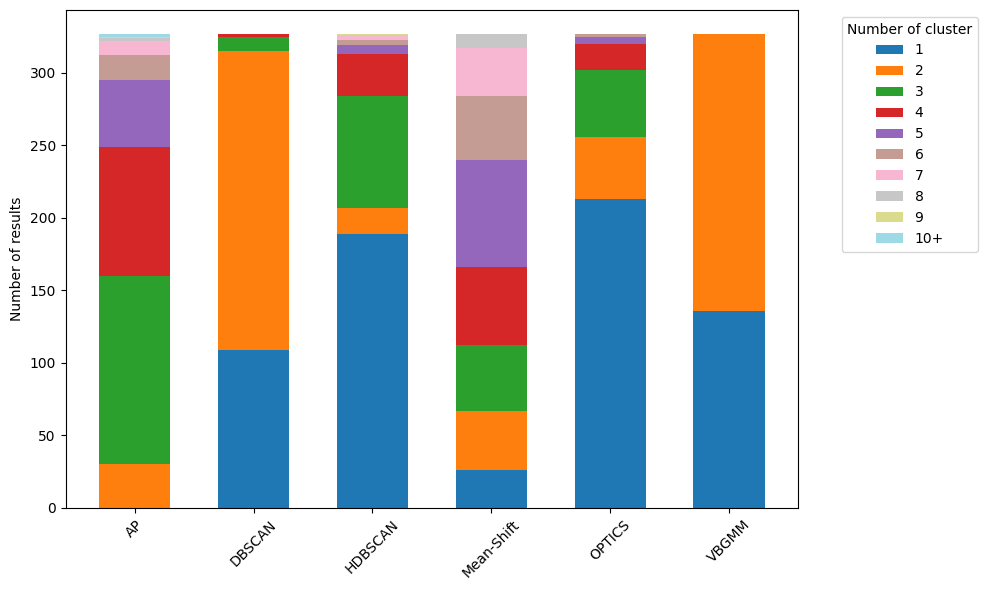

In [ ]:
plot_dist_nclusters_bar(scores_all_methods_df, max_cluster_display=10)
# plot_dist_nclusters_bar(scores_all_methods_df, title="Distribution of the number of clusters\nBRCA", max_cluster_display=10)



<br>

### **Median number of clusters (boxplot)**

* Display a boxplot illustrating the distribution of median number of clusters from the results of clustering methods when analyzing MAF tumor samples.

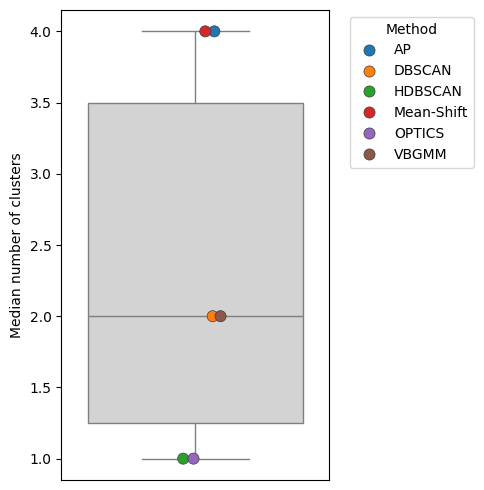

In [ ]:
plot_distr_median_nclusters(scores_all_methods_df)
# plot_distr_median_nclusters(scores_all_methods_df, title="Median number of clusters\nBRCA")


<br>

### **Distribution of cluster number (violin plot)**

* Display a violin plot that illustrates the distribution of the number of clusters from the results of clustering methods when analyzing MAF tumor samples.

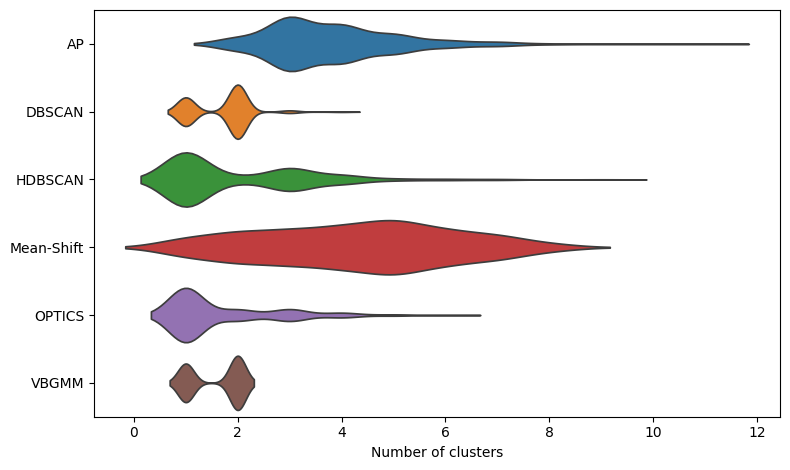

In [ ]:
plot_dist_nclusters_violin(scores_all_methods_df)
# plot_dist_nclusters_violin(scores_all_methods_df, title="Distribution of the number of clusters\nBRCA")


<br>

### **Filtering the methods**

- Filtering the methods with few clusters in their results.

- These methods will be excluded from the analysis because they group mutations into few clusters in most tumor samples.

In [ ]:
# Thresholds for filtering methods with few clusters
cluster_threshold = 2
percentage_threshold = 0.9

# Clustering by method and calculating the proportion of results with N_Cluster <= cluster_threshold
grouped = scores_all_methods_df.groupby("Method")["N_Cluster"].apply(
    lambda x: (x <= cluster_threshold).sum() / len(x)
)

# Selection of methods that have few clusters
methods_with_few_clusters = grouped[grouped >= percentage_threshold].index.tolist()

print(
    f"Methods with at least {int(percentage_threshold * 100)}% of results with {cluster_threshold} or fewer clusters: " +
    ", ".join(f'{method}' for method in methods_with_few_clusters))

# Generating a new DataFrame excluding methods with results with few clusters
scores_filtered_methods_df = scores_all_methods_df[~scores_all_methods_df["Method"].isin(methods_with_few_clusters)]


Methods with at least 90% of results with 2 or fewer clusters: DBSCAN, VBGMM


<br>

### **Correlation of cluster number**

- Display heatmap indicating Pearson correlation based on the number of clusters each method produced for each cancer sample.

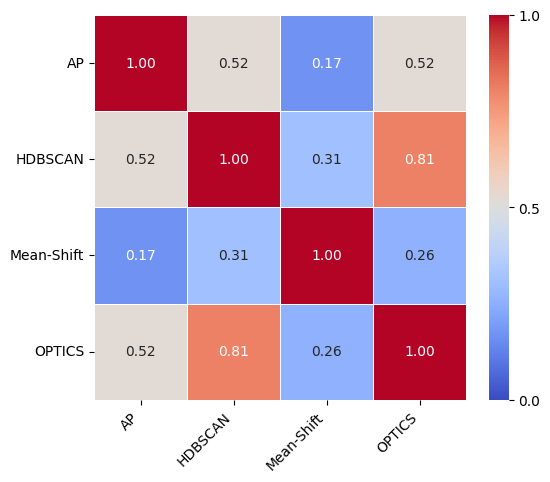

In [ ]:
plot_correlation_nclusters(scores_filtered_methods_df)
# plot_correlation_nclusters(scores_filtered_methods_df, title="Cluster number correlation\nBRCA")


<br>


### **Distribution of scores (boxplot)**

* Display boxplots to illustrate the distribution of scores of different clustering methods and MAF tumor samples.

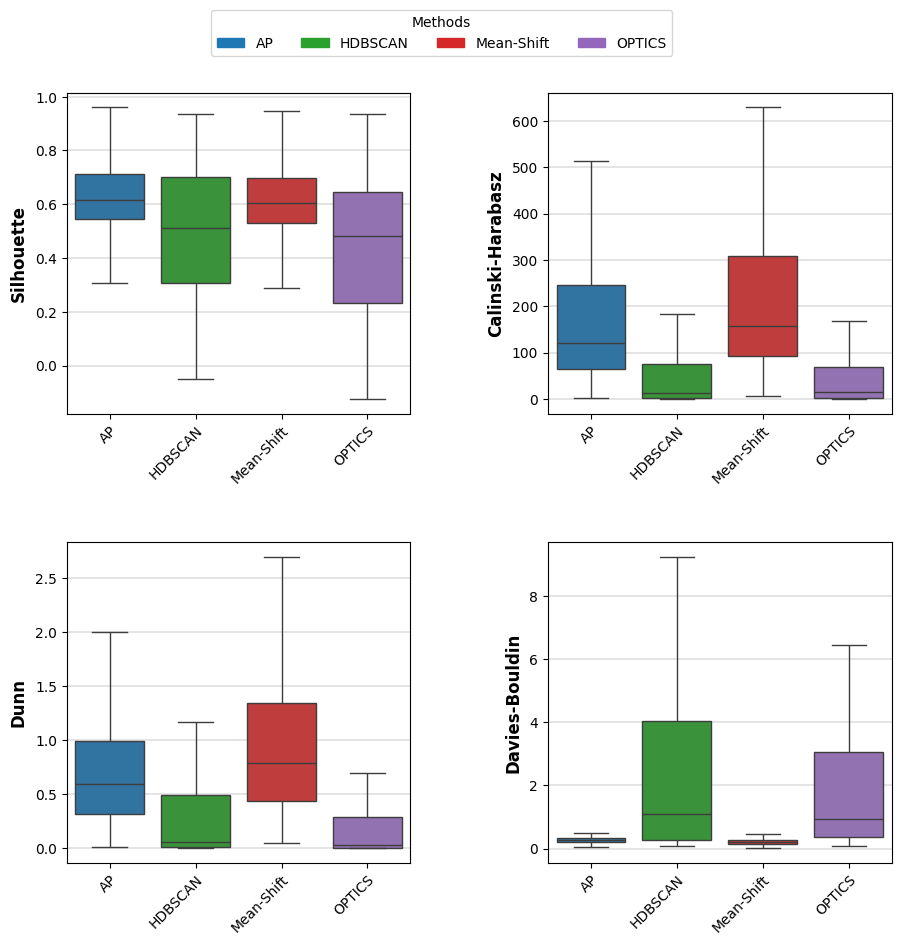

In [ ]:
# Create boxplots with the distribution of scores of different clustering methods and MAF tumor samples
plot_distribution_scores(scores_filtered_methods_df, means=False, fliers=False)
# plot_distribution_scores(scores_filtered_methods_df, means=False, fliers=False, title="Performance of clustering methods\nBRCA")


<br><br>

### **Means and standard deviations of metrics**

* Calculate the means and standard deviations of the metrics for each clustering method.

In [ ]:
metric_names = scores_filtered_methods_df.columns[-5:].tolist()
summary_stats = scores_filtered_methods_df.groupby("Method")[metric_names].agg(['mean', 'std', 'count'])
summary_stats.to_csv(f"{tables_output_dir}/Summary_Stats_Metrics.tsv", sep='\t')
summary_stats


N_Cluster                 Silhouette                  \
                mean       std count       mean       std count   
Method                                                            
AP          3.834862  1.341964   327   0.626765  0.125592   327   
HDBSCAN     2.006116  1.383500   327   0.497619  0.233087   138   
Mean-Shift  4.293578  1.855035   327   0.611532  0.129471   301   
OPTICS      1.669725  1.068699   327   0.451924  0.262368   114   

           Calinski-Harabasz                        Dunn                  \
                        mean         std count      mean       std count   
Method                                                                     
AP                232.646803  381.615122   327  0.944180  1.983862   327   
HDBSCAN            58.557919  107.339198   138  0.345369  0.667628   138   
Mean-Shift        348.150389  893.815629   301  1.247483  2.105433   301   
OPTICS             56.467542  115.467784   114  0.296617  0.704578   114   

           Davies-Bouldin                   
                     mean        std count  
Method                                      
AP               0.268488   0.091191   327  
HDBSCAN          5.267896  16.196263   138  
Mean-Shift       0.208865   0.095469   301  
OPTICS           3.953289  14.091501   114

<br><br><br>

---


# **8) Exporting results**

- This section allows the user to download the Output folder, which contains the generated plots, statistics, and any other result files produced during the analysis.

- The folder is first compressed into a .zip file, then a download button is displayed.

- By clicking the button, the zipped folder will be downloaded directly to the user’s computer.

In [ ]:
import shutil
import ipywidgets as widgets
from IPython.display import display
from google.colab import files

# Function to download the zip file
def on_download_button_clicked(b):
    files.download("Output.zip")

# Compact the Output folder
shutil.make_archive("Output", 'zip', "Output")

# Create download button
download_button = widgets.Button(description="Download Output", button_style='success')
download_button.on_click(on_download_button_clicked)
display(download_button)


Button(button_style='success', description='Download Output', style=ButtonStyle())